In [8]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Split train → train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape)

(40000, 32, 32, 3) (10000, 32, 32, 3) (10000, 32, 32, 3)
(40000, 10)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Strong CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Better optimizer
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Data augmentation (keep this)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train)

# Training helpers (VERY important)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    verbose=1
)

early = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early]
)

# Final evaluation
loss, acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", acc)

KeyboardInterrupt: 

In [4]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

loss, acc = model.evaluate(X_test, y_test)
print("Tuned Model Accuracy:", acc)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 130ms/step - accuracy: 0.3938 - loss: 1.6675 - val_accuracy: 0.5103 - val_loss: 1.3726
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.5323 - loss: 1.3109 - val_accuracy: 0.6025 - val_loss: 1.1366
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 133ms/step - accuracy: 0.5893 - loss: 1.1689 - val_accuracy: 0.6189 - val_loss: 1.0844
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 124ms/step - accuracy: 0.6248 - loss: 1.0661 - val_accuracy: 0.6564 - val_loss: 0.9772
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.6523 - loss: 0.9939 - val_accuracy: 0.6728 - val_loss: 0.9366
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 126ms/step - accuracy: 0.6743 - loss: 0.9344 - val_accuracy: 0.6891 - val_loss: 0.8833
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.6930 - loss: 0.8796 - val_accuracy: 0.7010 - val_loss: 0.8661
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.7104 - loss: 0

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1000
           1       0.85      0.83      0.84      1000
           2       0.70      0.59      0.64      1000
           3       0.55      0.54      0.54      1000
           4       0.67      0.71      0.69      1000
           5       0.64      0.65      0.65      1000
           6       0.78      0.82      0.80      1000
           7       0.77      0.78      0.77      1000
           8       0.83      0.84      0.83      1000
           9       0.80      0.81      0.80      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.73     10000
weighted avg       0.74      0.74      0.73     10000

[[791  12  36  19  17   7  12  10  61  35]
 [ 17 830   6  12   3   4   9   2  27  90]
 [ 59   4 589  62  91  64  72  39  13   7]
 [ 23   8  61 540  72 164  57  44  15  16]
 [ 23   2  41  65 715  34  

In [6]:
'''
Different hyperparameters affect how well the model learns.

Filters
Increasing the number of filters helps the model detect more features in images, which usually improves accuracy.
However, using too many filters can cause the model to memorize the training data instead of learning general patterns, which leads to overfitting.

Kernel Size
A kernel size of 3×3 works best in most cases because it captures important details without adding unnecessary complexity.
Larger kernels increase computation and do not always improve performance.

Learning Rate
The learning rate controls how fast the model learns. If it is too high, training becomes unstable and the model may not converge.
If it is too low, the training process becomes slow but more stable.

Batch Size
Smaller batch sizes usually help the model generalize better, but training takes more time.
Larger batch sizes make training faster, but may slightly reduce accuracy.

Dropout
Dropout helps prevent overfitting by randomly deactivating some neurons during training.
However, too much dropout can make the model too weak and lead to underfitting.

Optimizer
The optimizer controls how the model updates its weights. Adam is commonly used because it performs well in most cases without requiring much tuning.

Overfitting vs Underfitting

Overfitting
Overfitting occurs when the model performs very well on training data but poorly on validation or test data. 
A common sign is high training accuracy and low validation accuracy.
This can be reduced by using dropout, data augmentation, or simplifying the model.

Underfitting
Underfitting occurs when the model cannot learn the data properly. In this case, both training and validation accuracy remain low.
This can be improved by increasing model complexity, such as adding more layers or filters.

'''

'\nDifferent hyperparameters affect how well the model learns.\n\nFilters\nIncreasing the number of filters helps the model detect more features in images, which usually improves accuracy.\nHowever, using too many filters can cause the model to memorize the training data instead of learning general patterns, which leads to overfitting.\n\nKernel Size\nA kernel size of 3×3 works best in most cases because it captures important details without adding unnecessary complexity.\nLarger kernels increase computation and do not always improve performance.\n\nLearning Rate\nThe learning rate controls how fast the model learns. If it is too high, training becomes unstable and the model may not converge.\nIf it is too low, the training process becomes slow but more stable.\n\nBatch Size\nSmaller batch sizes usually help the model generalize better, but training takes more time.\nLarger batch sizes make training faster, but may slightly reduce accuracy.\n\nDropout\nDropout helps prevent overfitting

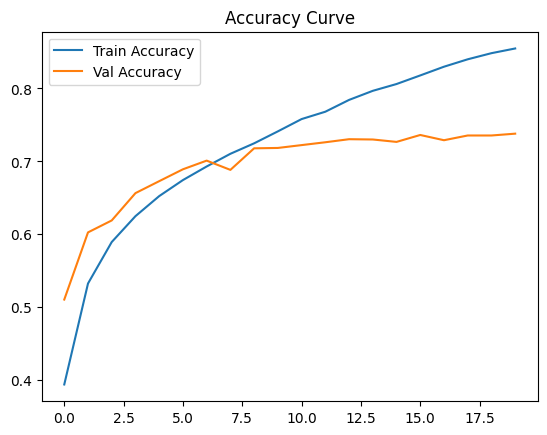

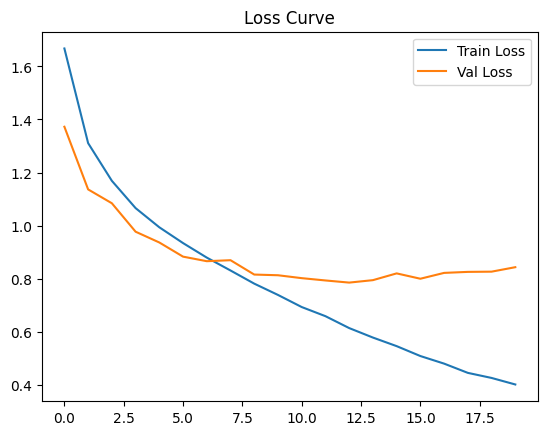

In [7]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()